In [ ]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/chNN/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Figure 6.4-5 &mdash; oxygen $T$&ndash;$\underline{S}$ diagram (thermo-package version)

Package version of the Figure 6.4-5 notebook: the Peng&ndash;Robinson EOS, its
entropy departure (`pr.departure_S`), and the fugacity/saturation solve come from
the shared `thermo` package. Compare with the self-contained
`PR_entropy_O2_example.ipynb`.

The ideal-gas entropy uses the $C_P$ coefficients on the `PengRobinson` object
(`pr.cp`); the reference state is the ideal gas at $25\,^{\circ}$C, 1 bar. Numbers
differ slightly from the self-contained notebook ($\omega = 0.025$,
$\kappa = 0.413$ vs. the book's $\kappa = 0.4069$).

Eric Furst

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import brentq

from thermo import PengRobinson
from thermo.peng_robinson import R

pr = PengRobinson.from_database("oxygen")
cA, cB, cC, cD = pr.cp
T_REF, P_REF = 298.15, 1e5      # ideal gas at 25 C, 1 bar -> S = 0
TO_KELVIN, BAR = 273.15, 1e5


def S_ideal(T, P):
    return (cA * np.log(T / T_REF) + cB * (T - T_REF)
            + cC / 2 * (T**2 - T_REF**2) + cD / 3 * (T**3 - T_REF**3)
            - R * np.log(P / P_REF))


def entropy(P, T, phase):
    """Molar entropy (J/mol K) rel. to the ideal gas at 25 C, 1 bar."""
    return S_ideal(T, P) + pr.departure_S(T, P, phase)


print(f"{pr.name}: Tc = {pr.Tc} K, Pc = {pr.Pc/1e5:.2f} bar, kappa = {pr.kappa:.4f}")
print(f"S(25 C, 1 bar) = {entropy(P_REF, T_REF, 'vapor'):.3f} J/(mol K)  (ref: 0)")


oxygen: Tc = 154.6 K, Pc = 50.40 bar, kappa = 0.4130
S(25 C, 1 bar) = -0.024 J/(mol K)  (ref: 0)


## Saturation temperature and the two-phase envelope

Bracket the equal-fugacity condition between the spinodal pressures (via
`pr.pressure` / `pr.ln_phi`), build the envelope table, and interpolate the
saturation temperature and entropies at each isobar.

In [2]:
def loop_pressure_bounds(T, n=4000):
    V = np.logspace(np.log10(1.001 * pr.b), np.log10(0.02), n)
    P = pr.pressure(V, T)
    turns = np.where(np.diff(np.sign(np.diff(P))) != 0)[0]
    if len(turns) < 2:
        return None
    return P[turns].min(), P[turns].max()


def Psat(T):
    bounds = loop_pressure_bounds(T)
    if bounds is None:
        return None
    P_lo, P_hi = max(1.0, bounds[0]) * 1.0001, bounds[1] * 0.9999
    resid = lambda P: pr.ln_phi(T, P, "liquid") - pr.ln_phi(T, P, "vapor")
    if resid(P_lo) * resid(P_hi) > 0:
        return None
    return brentq(resid, P_lo, P_hi, xtol=1.0, rtol=1e-12, maxiter=200)


frac = np.geomspace(2e-3, 1.0, 600)
T_list = np.sort(pr.Tc - (pr.Tc - 63.0) * frac)

rows = []
for T in T_list:
    ps = Psat(T)
    if ps is None:
        continue
    zs = pr.compressibility(T, ps)
    if len(zs) < 2 or (zs.max() - zs.min()) < 1e-7:
        continue
    rows.append({"T": T, "P": ps,
                 "SL": entropy(ps, T, "liquid"),
                 "SV": entropy(ps, T, "vapor")})

Sc = entropy(pr.Pc, pr.Tc, "vapor")
rows.append({"T": pr.Tc, "P": pr.Pc, "SL": Sc, "SV": Sc})

envelope = pd.DataFrame(rows).sort_values("T").reset_index(drop=True)
print(f"{len(envelope)} envelope points; critical S = {Sc:.2f} J/(mol K)")

def Tsat(P):  return np.interp(P, envelope["P"], envelope["T"])
def SL_at(P): return np.interp(P, envelope["P"], envelope["SL"])
def SV_at(P): return np.interp(P, envelope["P"], envelope["SV"])
envelope.tail()


601 envelope points; critical S = -67.32 J/(mol K)


,T,P,SL,SV
596,154.411008,5.005149e+06,-69.495030,-66.473037
597,154.412959,5.005512e+06,-69.486836,-66.480872
598,154.414889,5.005872e+06,-69.478683,-66.488669
599,154.416800,5.006228e+06,-69.470574,-66.496427
600,154.600000,5.040000e+06,-67.320549,-67.320549


## Figure 6.4-5

Same construction as the self-contained notebook, using the package throughout.

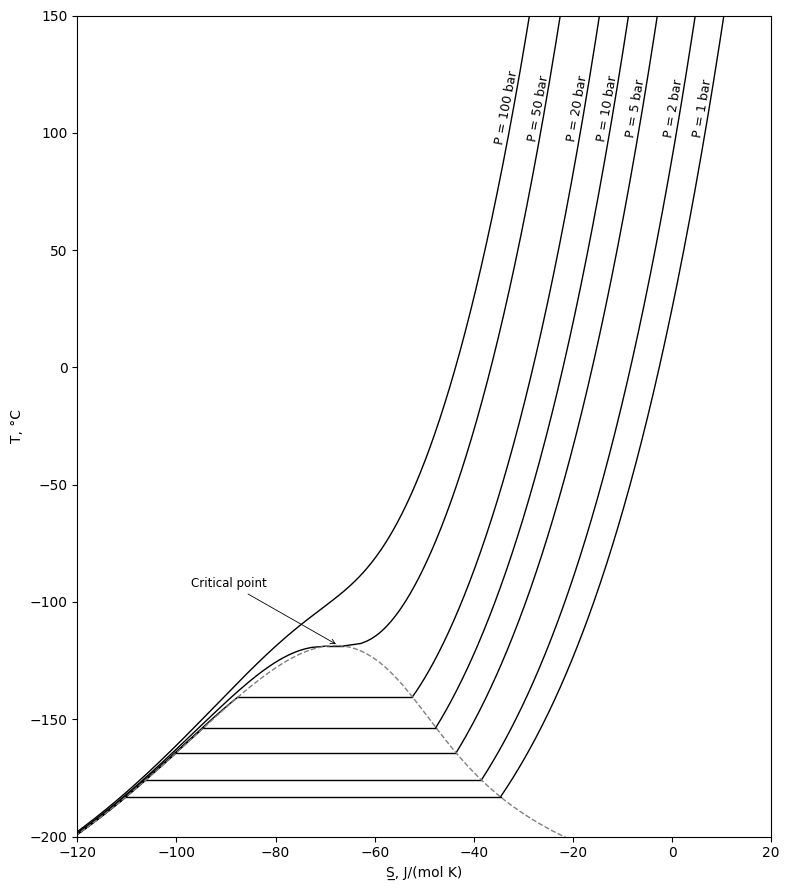

In [8]:
import os

fig, ax = plt.subplots(figsize=(8.0, 9.0))
BLACK = "black"

T_lo, T_hi = 63.0, 423.0
ax.set_xlim(-120, 20)
ax.set_ylim(-200, 150)


def S_branch(P, T_from, T_to, phase, n):
    T = np.linspace(T_from, T_to, n)
    return np.array([entropy(P, t, phase) for t in T]), T - TO_KELVIN


def slope_angle(P, T_K, phase):
    s1 = entropy(P, T_K, phase);       p1 = ax.transData.transform((s1, T_K - TO_KELVIN))
    s2 = entropy(P, T_K + 2.0, phase); p2 = ax.transData.transform((s2, T_K + 2.0 - TO_KELVIN))
    return np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))


for Pbar in [1, 2, 5, 10, 20, 50, 100]:
    P = Pbar * BAR
    if P >= pr.Pc:
        S, T = S_branch(P, T_lo, T_hi, "vapor", 400)
        ax.plot(S, T, "-", color=BLACK, lw=1)
    else:
        Ts = Tsat(P)
        Sl, Tl = S_branch(P, T_lo, Ts, "liquid", 150)
        Sv, Tv = S_branch(P, Ts, T_hi, "vapor", 250)
        ax.plot(Sl, Tl, "-", color=BLACK, lw=1)
        ax.plot(Sv, Tv, "-", color=BLACK, lw=1)
        ax.plot([SL_at(P), SV_at(P)], [Ts - TO_KELVIN, Ts - TO_KELVIN],
                "-", color=BLACK, lw=1)
        # ax.text(SL_at(P) - 2, Ts - TO_KELVIN, f"P = {Pbar} bar", fontsize=7.5,
        #         ha="right", va="center")

    T_lab = 110 + TO_KELVIN
    S_lab = entropy(P, T_lab, "vapor")
    ax.text(S_lab, T_lab - TO_KELVIN, f"P = {Pbar} bar", fontsize=9,
            rotation=slope_angle(P, T_lab, "vapor"), rotation_mode="anchor",
            ha="center", va="bottom")

ax.plot(envelope.SL, envelope["T"] - TO_KELVIN, "--", color="gray", lw=1)
ax.plot(envelope.SV, envelope["T"] - TO_KELVIN, "--", color="gray", lw=1)
ax.annotate("Critical point",
            xy=(Sc, pr.Tc - TO_KELVIN), xytext=(Sc - 22, pr.Tc - TO_KELVIN + 25),
            fontsize=8.5, ha="center",
            arrowprops=dict(arrowstyle="->", lw=0.6, color=BLACK))

ax.set_xlabel("S̲, J/(mol K)")
ax.set_ylabel("T, °C")

os.makedirs("pdf", exist_ok=True)
plt.tight_layout()
plt.savefig("pdf/Fig_6.4-5_thermo.pdf", dpi=300, bbox_inches="tight")
plt.show()
